In [6]:
import pandas as pd

# Path to saved regime csv
path = '/Users/developmentserver/Desktop/spy.csv'

df = pd.read_csv(path) 
df

,date,current_regime,forecast_regime,p0_current,p1_current,p2_current,p0_forecast,p1_forecast,p2_forecast,entropy_current,entropy_forecast
0,2021-01-31,1,2,5.125304e-03,0.755638,0.239237,7.426118e-02,0.359188,0.566551,0.528789,0.803537
1,2021-02-28,2,1,5.278910e-03,0.437890,0.556831,8.465232e-02,0.487076,0.428272,0.651101,0.839758
2,2021-03-31,2,1,1.732258e-03,0.492109,0.506159,6.795802e-02,0.472934,0.459108,0.641348,0.813995
3,2021-04-30,1,2,1.945095e-03,0.615806,0.382249,7.020538e-02,0.418126,0.511669,0.617417,0.813700
4,2021-05-31,1,2,1.896702e-03,0.565076,0.433027,7.484142e-02,0.461895,0.463263,0.634304,0.825820
5,2021-06-30,1,2,1.539993e-03,0.583892,0.414568,6.937574e-02,0.431351,0.499274,0.627305,0.814300
6,2021-07-31,1,1,2.215703e-03,0.509361,0.488423,7.077631e-02,0.480377,0.448847,0.643674,0.818484
7,2021-08-31,2,1,2.016625e-03,0.382420,0.615563,6.850270e-02,0.538041,0.393457,0.617865,0.804785
8,2021-09-30,1,1,4.714028e-03,0.994802,0.000484,4.837045e-02,0.923667,0.027963,0.031068,0.291158
9,2021-10-31,2,1,2.062946e-03,0.156929,0.841008,6.254081e-02,0.719460,0.217999,0.408704,0.675684


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yfinance as yf


def plot_regime_forecast(
    results: pd.DataFrame,
    ticker: str,
    feature_set: str = 'returns',
    regime_labels: list[str] | None = None,
    start: str | None = None,
    end: str | None = None,
    figsize: tuple = (14, 8),
) -> None:
    # ── Normalise index ──────────────────────────────────────────────────────
    df = results.copy()
    if 'date' in df.columns:
        df = df.set_index('date')
    df.index = pd.to_datetime(df.index)

    # ── Date filter ─────────────────────────────────────────────────────────
    if start:
        df = df.loc[start:]
    if end:
        df = df.loc[:end]

    if df.empty:
        raise ValueError(f'No data in range [{start}, {end}]')

    k = int(df['forecast_regime'].max()) + 1
    if regime_labels is None:
        regime_labels = [f'Regime {i}' for i in range(k)]

    if feature_set == 'macro':
        colors = ['#2ecc71', '#f39c12', '#e74c3c'][:k]
    else:
        colors = ['#e74c3c', '#f39c12', '#2ecc71'][:k]

    # ── Conformity colours ───────────────────────────────────────────────────
    # Determined by which probability is the lowest at each time step:
    #   p2 is lowest  →  p0 + p1 conformity (p1 moving with p0)  → purple
    #   p0 is lowest  →  p1 + p2 conformity (p1 moving with p2)  → teal
    #   p1 is lowest  →  p1 is weak, no conformity
    conf_color_p01 = '#8e44ad'   # purple — p1 aligns with p0
    conf_color_p12 = '#16a085'   # teal   — p1 aligns with p2

    # ── Compute conformity per row ───────────────────────────────────────────
    fcast_cols = [f'p{i}_forecast' for i in range(k)]
    prob_df  = df[fcast_cols]
    min_idx  = prob_df.values.argmin(axis=1)
    conformity = pd.Series(
        ['p01' if m == 2 else ('p12' if m == 0 else None) for m in min_idx],
        index=df.index,
    )

    # ── Fetch monthly close (scoped to filtered range) ───────────────────────
    fetch_start = df.index[0].strftime('%Y-%m-%d')
    fetch_end   = df.index[-1].strftime('%Y-%m-%d')
    raw   = yf.download(ticker, start=fetch_start, end=fetch_end, auto_adjust=True, progress=False)
    price = raw['Close'].resample('ME').last().dropna()

    # ── Layout ───────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.04},
    )

    # ── Top: price + regime shading ──────────────────────────────────────────
    ax1.plot(price.index, price.values, color='#1a252f', linewidth=1.2, zorder=3)
    ax1.set_yscale('log')
    ax1.set_ylabel('Price  (log scale)', fontsize=11)

    date_range_str = f'{fetch_start} → {fetch_end}'
    ax1.set_title(f'{ticker}  —  HMM Forecast Regime  ({date_range_str})', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.35)

    dates   = df.index.tolist()
    regimes = df['forecast_regime'].tolist()

    for i, (x0, reg) in enumerate(zip(dates, regimes)):
        x1 = dates[i + 1] if i + 1 < len(dates) else x0 + pd.DateOffset(months=1)
        ax1.axvspan(x0, x1, alpha=0.22, color=colors[reg], zorder=1)

    patches = [
        mpatches.Patch(color=colors[i], alpha=0.7, label=regime_labels[i])
        for i in range(k)
    ]
    ax1.legend(handles=patches, loc='upper left', fontsize=10)

    # ── Bottom: stacked forecast probabilities + conformity shading ──────────
    prob_arr = prob_df.values.T

    ax2.stackplot(df.index, prob_arr, labels=regime_labels, colors=colors, alpha=0.80)

    # Overlay conformity spans
    conf_dates = df.index.tolist()
    conf_vals  = conformity.tolist()
    for i, (x0, cv) in enumerate(zip(conf_dates, conf_vals)):
        if cv is None:
            continue
        x1 = conf_dates[i + 1] if i + 1 < len(conf_dates) else x0 + pd.DateOffset(months=1)
        c  = conf_color_p01 if cv == 'p01' else conf_color_p12
        ax2.axvspan(x0, x1, alpha=0.28, color=c, zorder=2)

    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Forecast P', fontsize=10)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax2.grid(axis='x', linestyle='--', alpha=0.3)

    conf_patches = [
        mpatches.Patch(color=conf_color_p01, alpha=0.7, label='p0 ∥ p1  conformity'),
        mpatches.Patch(color=conf_color_p12, alpha=0.7, label='p1 ∥ p2  conformity'),
    ]
    ax2.legend(handles=conf_patches, loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.show()


/var/folders/hm/wjf212gn065g66t2hgmj94tc0000gn/T/ipykernel_5888/1317446464.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


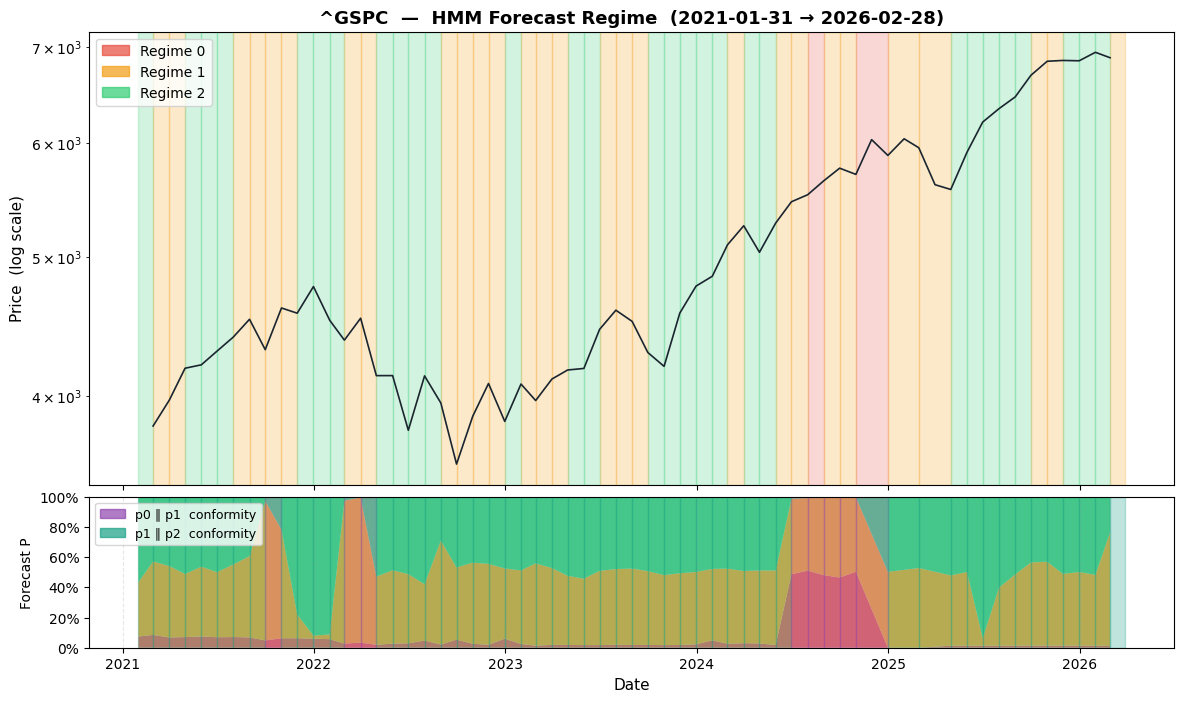

In [8]:
# plot_regime_forecast(df, 'AAPL', feature_set='macro', start='2020-01-01', end='2023-01-01')   # green=calm, red=stress
plot_regime_forecast(df, '^GSPC', feature_set='returns')  # red=bear, green=bull
# plot_regime_forecast(df, 'SPY', feature_set='rvv')      # red=bear, green=bull


Depending on the feature set, the market regimes will be displayed differently. 

For the feature set of Macro the regime states are as follows:
- Regime 0 - growth/bullish
- Regime 1 - stationary
- Regime 2 - high stress/bear

For returns only or rvv feature sets, the regime states are as follows:
- Regime 0 - high stress/bear
- Regime 1 - stationary
- Regime 2 - growth/bullish